# BÀI TẬP VỀ NHÀ: GAN sinh ảnh chữ số MNIST
**Sinh viên:** Đoàn Tấn Minh Tân

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(mnist, batch_size=128, shuffle=True, drop_last=True)

Device: cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 993kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.29MB/s]


In [2]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
num_epochs = 50
milestone_epochs = [0, 9, 29, 49]
snapshots = {}
loss_D_hist, loss_G_hist = [], []

for epoch in range(num_epochs):
    G.train(); D.train()
    epoch_loss_D, epoch_loss_G, n_batches = 0.0, 0.0, 0

    for real_imgs, _ in loader:
        bsz = real_imgs.size(0)
        real_imgs = real_imgs.view(bsz, -1).to(device)

        opt_D.zero_grad()
        real_logits = D(real_imgs)
        z = torch.randn(bsz, z_dim, device=device)
        fake_imgs = G(z).detach()
        fake_logits = D(fake_imgs)
        loss_D = (criterion(real_logits, torch.ones_like(real_logits))
                + criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
        loss_D.backward()
        opt_D.step()

        opt_G.zero_grad()
        z = torch.randn(bsz, z_dim, device=device)
        fake_logits = D(G(z))
        loss_G = criterion(fake_logits, torch.ones_like(fake_logits))
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        n_batches += 1

    loss_D_hist.append(epoch_loss_D / n_batches)
    loss_G_hist.append(epoch_loss_G / n_batches)

    if epoch in milestone_epochs:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, z_dim, device=device)
            samples = G(z).view(-1, 28, 28).cpu().numpy()
        snapshots[epoch] = samples

    print(f'Epoch {epoch+1:3d}/{num_epochs}  '
          f'L_D = {loss_D_hist[-1]:.4f}  L_G = {loss_G_hist[-1]:.4f}')

Epoch   1/50  L_D = 0.6476  L_G = 0.8199
Epoch   2/50  L_D = 0.6361  L_G = 0.9007
Epoch   3/50  L_D = 0.6270  L_G = 0.9447
Epoch   4/50  L_D = 0.6090  L_G = 1.0002
Epoch   5/50  L_D = 0.6061  L_G = 1.0048
Epoch   6/50  L_D = 0.6153  L_G = 0.9715
Epoch   7/50  L_D = 0.6232  L_G = 0.9238
Epoch   8/50  L_D = 0.6297  L_G = 0.9004
Epoch   9/50  L_D = 0.6321  L_G = 0.8862
Epoch  10/50  L_D = 0.6343  L_G = 0.8802
Epoch  11/50  L_D = 0.6377  L_G = 0.8735
Epoch  12/50  L_D = 0.6441  L_G = 0.8569
Epoch  13/50  L_D = 0.6437  L_G = 0.8538
Epoch  14/50  L_D = 0.6463  L_G = 0.8498
Epoch  15/50  L_D = 0.6488  L_G = 0.8433
Epoch  16/50  L_D = 0.6515  L_G = 0.8348
Epoch  17/50  L_D = 0.6534  L_G = 0.8280
Epoch  18/50  L_D = 0.6565  L_G = 0.8256
Epoch  19/50  L_D = 0.6590  L_G = 0.8167
Epoch  20/50  L_D = 0.6607  L_G = 0.8139
Epoch  21/50  L_D = 0.6621  L_G = 0.8085
Epoch  22/50  L_D = 0.6630  L_G = 0.8043
Epoch  23/50  L_D = 0.6644  L_G = 0.8028
Epoch  24/50  L_D = 0.6651  L_G = 0.7972
Epoch  25/50  L_

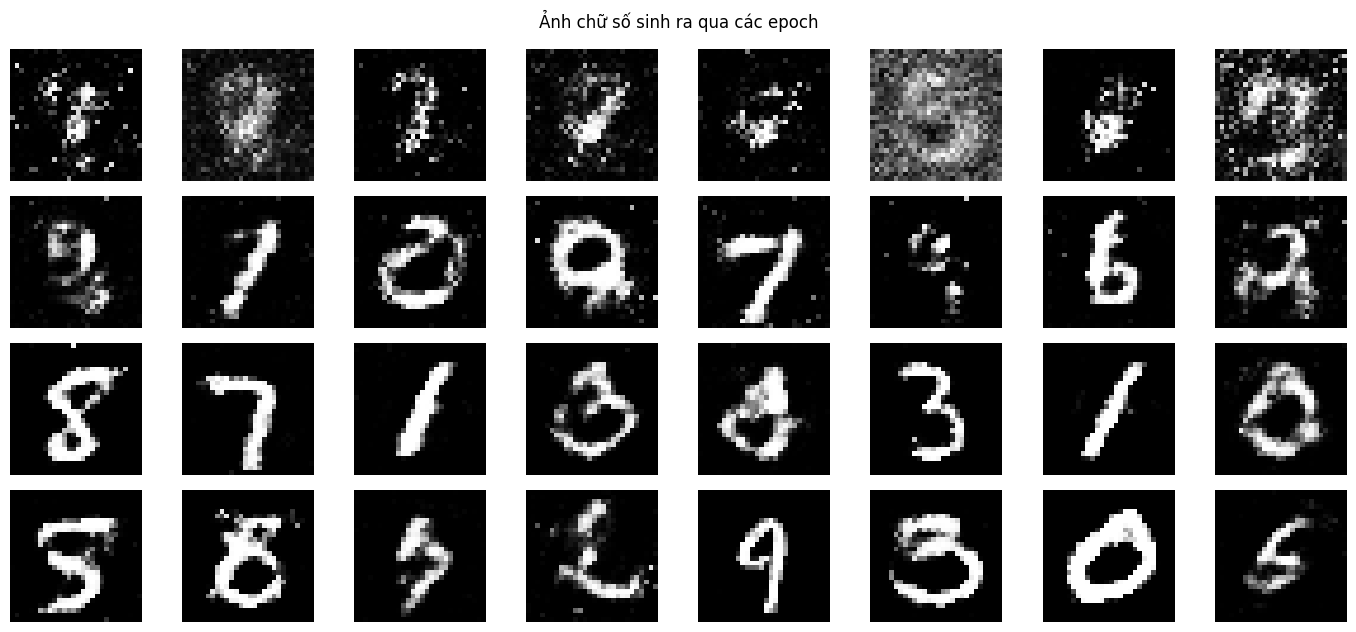

In [4]:
# Vẽ ảnh giả ở các milestone
fig, axes = plt.subplots(len(milestone_epochs), 8, figsize=(14, 1.6 * len(milestone_epochs)))
for r, ep in enumerate(milestone_epochs):
    if ep not in snapshots:
        continue
    for c in range(8):
        axes[r, c].imshow(snapshots[ep][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'Epoch {ep+1}', fontsize=12, rotation=0, ha='right', va='center')
plt.suptitle('Ảnh chữ số sinh ra qua các epoch')
plt.tight_layout()
plt.show()

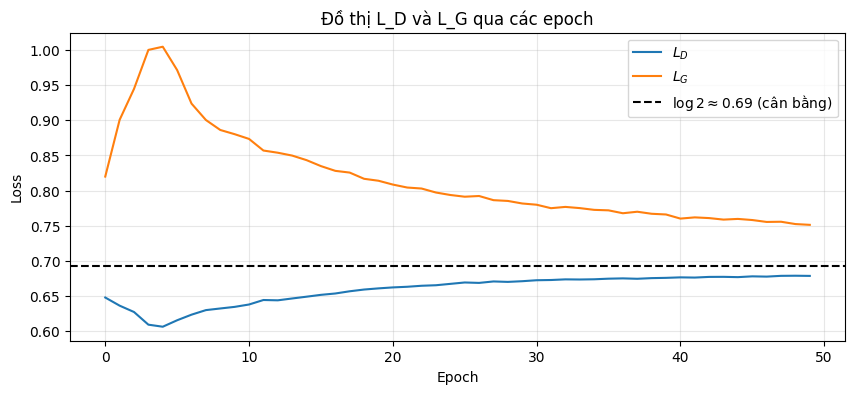

In [5]:
# Vẽ loss
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='$L_D$')
plt.plot(loss_G_hist, label='$L_G$')
plt.axhline(np.log(2), color='black', linestyle='--', label=r'$\log 2 \approx 0.69$ (cân bằng)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Đồ thị L_D và L_G qua các epoch')
plt.show()

## Nhận xét

**Loss có dao động quanh log(2) không?**  
Loss: LDL_D
LD​ tiệm cận log(2) từ phía dưới (0.6784 ở epoch 50), LGL_G
LG​ vẫn còn cao hơn (0.751) — GAN chưa đạt cân bằng hoàn toàn nhưng đang hội tụ đúng hướng. Cần thêm epoch để hai đường gặp nhau.

**Sau 50 epoch, chữ số sinh ra thế nào?**  
Tiến trình rõ — epoch 1 ra nhiễu, epoch 10 mờ có hình dạng, epoch 30–50 nhận ra được chữ số, đa dạng.

**Có hiện tượng mode collapse không?**  
Không xảy ra — snapshot epoch 50 cho thấy đủ loại chữ số 0–9.